# Support Vector Machine (SVM)

In [3]:

import os
import sys
import pickle

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [5]:

from src.preprocessing import basic_clean
from src.features import get_tfidf_features
from src.evaluate import evaluate_model

In [6]:
pd.set_option("display.max_colwidth", 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [7]:

# File paths 

TRAIN_PATH = "../datasets/processed/train_split.csv"
VAL_PATH = "../datasets/processed/val_split.csv"
TEST_PATH = "../datasets/processed/test_split.csv"

MODEL_DIR = "../saved_models"

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "svm.pkl"
)

VECTORIZER_PATH = os.path.join(
    MODEL_DIR,
    "svm_tfidf_vectorizer.pkl"
)

RESULTS_DIR = "../results"

RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "model_comparison.csv"
)

CONFUSION_MATRIX_DIR = os.path.join(
    RESULTS_DIR,
    "confusion_matrices"
)


In [8]:

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CONFUSION_MATRIX_DIR, exist_ok=True)

print("File paths are ready!")
print("Model directory:", MODEL_DIR)
print("Results directory:", RESULTS_DIR)
print("Confusion matrix directory:", CONFUSION_MATRIX_DIR)

File paths are ready!
Model directory: ../saved_models
Results directory: ../results
Confusion matrix directory: ../results\confusion_matrices


In [9]:

# Load datasets

try:
    train_df = pd.read_csv(TRAIN_PATH)
    val_df = pd.read_csv(VAL_PATH)
    test_df = pd.read_csv(TEST_PATH)

    print("Datasets loaded successfully!\n")

    print("Training set:", train_df.shape)
    print("Validation set:", val_df.shape)
    print("Test set:", test_df.shape)

except FileNotFoundError as e:
    print("Error: Could not find one of the dataset files.")
    print("Please check the file paths.")
    print(e)

Datasets loaded successfully!

Training set: (4288, 2)
Validation set: (920, 2)
Test set: (920, 2)


In [10]:
required_columns = ["text", "label"]

for name, df in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        print(f"{name} set is missing: {missing_columns}")
    else:
        print(f"{name} set: OK")

print("\nExample training data:")
display(train_df[["text", "label"]].head())

Training set: OK
Validation set: OK
Test set: OK

Example training data:


,text,label
0,mama ke dabre se bahir a gaye ho kya baat ha chote bacha ka rape howa tha qasoor me baad me pata...,1
1,chinta kt kro beta madhur tmko tmri bhakti ke lie rajya sabha mn entry mil jaegi bo bhi rape ke ...,0
2,modi ka to pata nahi par aj vi delhi me rape ro raha hai tum log sirf modi modi modi ka mala jap...,0
3,teri gaand ka business,1
4,aur hum par terrorism ka label lagane wale duniya ache tarah jante hai aur tu bhe india is the m...,1


In [11]:
# tf-idf feature extraction

X_train, X_val, vectorizer = get_tfidf_features(
    train_texts=train_df["text"],
    test_texts=val_df["text"],
    ngram_range=(1, 2),
    max_features=20000
)

y_train = train_df["label"]
y_val = val_df["label"]

print("TF-IDF feature extraction completed!\n")

print("Training feature shape:", X_train.shape)
print("Validation feature shape:", X_val.shape)

TF-IDF feature extraction completed!

Training feature shape: (4288, 20000)
Validation feature shape: (920, 20000)


In [12]:
# Train the Linear SVM model
model = LinearSVC(
    C=1.0,
    max_iter=10000,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Model classes:", model.classes_)
print("Linear SVM trained successfully!")

Model classes: [0 1]
Linear SVM trained successfully!


In [13]:
print("Unique labels:", sorted(train_df["label"].unique()))
print("\nLabel distribution:")
print(train_df["label"].value_counts())

Unique labels: [0, 1]

Label distribution:
label
0    2503
1    1785
Name: count, dtype: int64


In [14]:
# Valuation evaluation

val_predictions = model.predict(X_val)

val_results = evaluate_model(
    y_true=y_val,
    y_pred=val_predictions,
    model_name="Linear SVM - Validation"
)

print("Validation Results:")
print(val_results)

Validation Results:
{'model': 'Linear SVM - Validation', 'accuracy': 0.7228260869565217, 'precision': 0.7, 'recall': 0.5848563968668408, 'f1': 0.6372688477951636}


In [15]:
#sample predictions

import re

sample_comments = [
    "tu bilkul bekaar hai, mar ja",
    "thank you so much bhai",
    "kal milte hain, take care"
]

cleaned_samples = [
    basic_clean(comment)
    for comment in sample_comments
]

sample_features = vectorizer.transform(cleaned_samples)

sample_predictions = model.predict(sample_features)

sample_scores = model.decision_function(sample_features)

print("Sample Predictions:\n")

for comment, prediction, score in zip(
    sample_comments,
    sample_predictions,
    sample_scores
):

    label = (
        "OFFENSIVE"
        if prediction == 1
        else "NOT OFFENSIVE"
    )

    print(f"Prediction     : {label}")
    print(f"Decision score : {score:+.4f}")
    print(f"Comment        : {comment}")
    print("-" * 60)

Sample Predictions:

Prediction     : OFFENSIVE
Decision score : +0.2532
Comment        : tu bilkul bekaar hai, mar ja
------------------------------------------------------------
Prediction     : NOT OFFENSIVE
Decision score : -0.5257
Comment        : thank you so much bhai
------------------------------------------------------------
Prediction     : OFFENSIVE
Decision score : +0.1435
Comment        : kal milte hain, take care
------------------------------------------------------------


In [16]:
vocab = vectorizer.vocabulary_

check_words = [
    "tu",
    "bekaar",
    "mar",
    "ja",
    "bkl",
    "bhai"
]

print("Vocabulary Check:\n")

for word in check_words:

    if word in vocab:

        print(
            f"{word:10s} -> FOUND "
            f"(index: {vocab[word]})"
        )

    else:

        print(
            f"{word:10s} -> NOT FOUND"
        )

Vocabulary Check:

tu         -> FOUND (index: 16445)
bekaar     -> NOT FOUND
mar        -> FOUND (index: 9017)
ja         -> FOUND (index: 3999)
bkl        -> NOT FOUND
bhai       -> FOUND (index: 1225)


In [17]:
feature_names = vectorizer.get_feature_names_out()
weights = model.coef_[0]

weights_df = pd.DataFrame({
    "word": feature_names,
    "weight": weights
})

top_offensive = weights_df.sort_values("weight", ascending=False).head(15)
top_safe = weights_df.sort_values("weight", ascending=True).head(15)

print("Top 15 words pushing toward OFFENSIVE:")
print(top_offensive.to_string(index=False))

print("\nTop 15 words pushing toward NOT OFFENSIVE:")
print(top_safe.to_string(index=False))

Top 15 words pushing toward OFFENSIVE:
         word   weight
    nafrat ho 1.503785
      chutiya 1.433142
terrorism aur 1.368151
     hate you 1.352898
       sharam 1.302669
         lund 1.237747
         chut 1.174546
         bani 1.113195
      chingri 1.112804
        kutte 1.068736
        dunga 1.064787
          pay 1.061015
     ladki ka 1.057576
     delhi me 1.051172
       gandhi 1.049667

Top 15 words pushing toward NOT OFFENSIVE:
     word    weight
     rape -3.061012
terrorism -2.685044
   tu toh -2.523675
    khoon -2.238403
     love -1.772311
       tu -1.628488
   hatred -1.606724
     bhai -1.596898
     good -1.490737
      toh -1.477206
      hai -1.469380
   hitler -1.445112
     arey -1.391557
      bro -1.276244
     mast -1.238121


In [18]:
# Save the trained model and vectorizer

try:
    with open(MODEL_PATH, "wb") as file:
        pickle.dump(model, file)

    with open(VECTORIZER_PATH, "wb") as file:
        pickle.dump(vectorizer, file)

    print("Model saved successfully!")
    print(f"Model: {MODEL_PATH}")
    print(f"Vectorizer: {VECTORIZER_PATH}")

except Exception as e:
    print("Error while saving model:", e)

Model saved successfully!
Model: ../saved_models\svm.pkl
Vectorizer: ../saved_models\svm_tfidf_vectorizer.pkl


In [19]:
# Final test evaluation

X_test = vectorizer.transform(test_df["text"])

y_test = test_df["label"]

test_predictions = model.predict(X_test)


test_results = evaluate_model(
    y_true=y_test,
    y_pred=test_predictions,
    model_name="Linear SVM - Test"
)

print("\nFinal Test Results:")
print(test_results)


Final Test Results:
{'model': 'Linear SVM - Test', 'accuracy': 0.7445652173913043, 'precision': 0.75, 'recall': 0.5796344647519582, 'f1': 0.6539027982326951}


In [20]:

y_test_pred = model.predict(X_test)

print("Test predictions generated successfully!")
print("Number of predictions:", len(y_test_pred))
print("Number of actual labels:", len(y_test))

Test predictions generated successfully!
Number of predictions: 920
Number of actual labels: 920


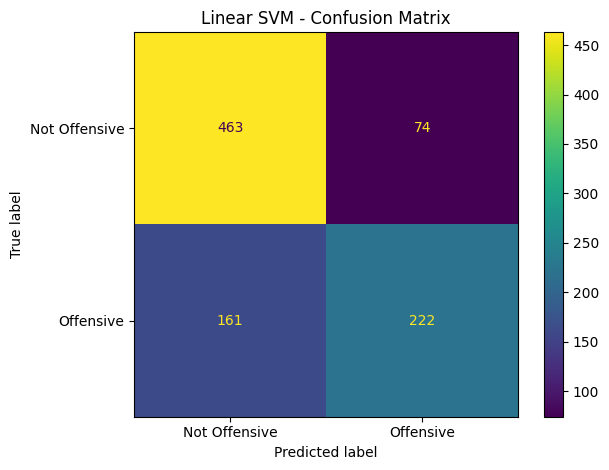

Confusion matrix saved to:
../results\confusion_matrices\linear_svm.png


In [21]:
# Confusion Matrix for Naive Bayes

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Offensive", "Offensive"]
)

disp.plot()

plt.title("Linear SVM - Confusion Matrix")
plt.tight_layout()

CONFUSION_MATRIX_PATH = os.path.join(
    CONFUSION_MATRIX_DIR,"linear_svm.png"
)

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to:")
print(CONFUSION_MATRIX_PATH)

In [23]:
# Save Linear SVM test results

def log_result(results_dict, results_path):
    results_row = pd.DataFrame([results_dict])

    if os.path.exists(results_path):
        existing_results = pd.read_csv(results_path)
        updated_results = pd.concat(
            [existing_results, results_row],
            ignore_index=True
        )
        
    else:
        updated_results = results_row

    # Save updated results
    updated_results.to_csv(
        results_path,
        index=False
    )
    print(f"Results saved to: {results_path}")

log_result(
    test_results,
    RESULTS_PATH
)

Results saved to: ../results\model_comparison.csv


In [24]:
if os.path.exists(RESULTS_PATH):
    results_df = pd.read_csv(RESULTS_PATH)
    display(results_df)

else:
    print("No comparison results file found.")

,model,accuracy,precision,recall,f1
0,Naive Bayes - Test,0.713043,0.856287,0.373368,0.520000
1,Logistic Regression - Test,0.751087,0.823529,0.511749,0.631240
2,Linear SVM - Test,0.744565,0.750000,0.579634,0.653903
3,Linear SVM - Test,0.744565,0.750000,0.579634,0.653903
4,Logistic Regression - Test,0.751087,0.823529,0.511749,0.631240
